# Case Study: End-to-end visualization and reporting project
`datasetcollection--->data cleaning--->data transformation--->EDA--->visualization chart----->Insight`

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## Dataset Collection

In [3]:
df=pd.read_csv('retail_store_sales.csv')
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


## Data Cleaning

In [4]:
df.columns

Index(['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit',
       'Quantity', 'Total Spent', 'Payment Method', 'Location',
       'Transaction Date', 'Discount Applied'],
      dtype='object')

In [5]:
df.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)


Skewness measures asymmetry of data
- If skew ≈ 0 (or between −0.5 and +0.5) → Mean
- If skew magnitude is greater than ~0.5 → Median
- If skew is ±1 or more → Definitely Median

In [7]:
df['Price Per Unit'].skew()


np.float64(-0.034976923344078786)

In [8]:
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Price Per Unit'].mean())

In [9]:
df['Total Spent'].skew()

np.float64(0.831294784172062)

In [10]:
df['Total Spent'] = df['Total Spent'].fillna(df['Total Spent'].median())


In [11]:
df.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit         0
Quantity             604
Total Spent            0
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

In [12]:
df['Quantity'].skew()

np.float64(-0.011947713822514437)

In [13]:
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].mean())



In [14]:
df['Item'] = df['Item'].fillna(df['Item'].mode()[0])


In [15]:
df['Discount Applied'] = df['Discount Applied'].fillna(False)


C:\Users\mausa\AppData\Local\Temp\ipykernel_22560\2334321945.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Discount Applied'] = df['Discount Applied'].fillna(False)


In [16]:
df.isnull().sum()

Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64

## Data Transformation

In [17]:
df['Discount Applied'] = df['Discount Applied'].astype(int)  # 0---> false,  1----->True
                                                            
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,1
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,1
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,0
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,0
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,0


In [18]:
df['Location']

0          Online
1          Online
2          Online
3          Online
4          Online
           ...   
12570    In-store
12571      Online
12572      Online
12573      Online
12574      Online
Name: Location, Length: 12575, dtype: object

### One-hot encoding

In [19]:
# Using pandas get_dummies
df_encoded = pd.get_dummies(df, columns=['Location'], prefix='Loc')
df_encoded.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Transaction Date,Discount Applied,Loc_In-store,Loc_Online
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,2024-04-08,1,False,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,2023-07-23,1,False,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,2022-10-05,0,False,True
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,2022-05-07,0,False,True
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,2022-10-02,0,False,True


## EDA + Visualization + Insight

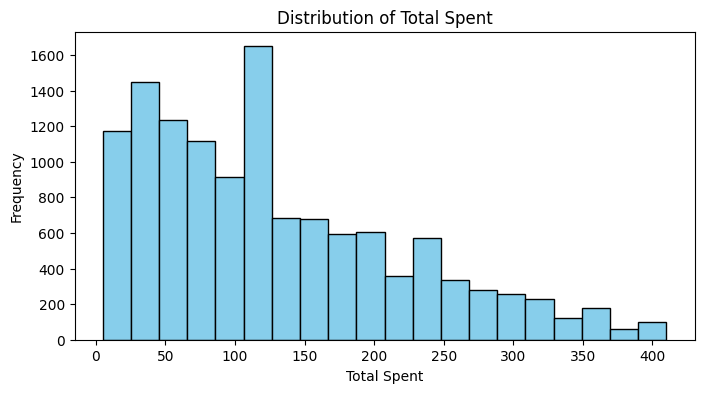

In [20]:

# Histogram for Total Spent
plt.figure(figsize=(8, 4))
plt.hist(df['Total Spent'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Total Spent')
plt.ylabel('Frequency')
plt.title('Distribution of Total Spent')
plt.show()

### Insight: Distribution of Total Spent

1. **Distribution Shape**: The histogram shows the distribution of customer spending amounts. 
   - If **right-skewed** (tail on right): Most customers spend smaller amounts, with few high spenders.
   - If **left-skewed** (tail on left): Most customers spend higher amounts.
   - If **symmetric/bell-shaped**: Spending is normally distributed around the mean.

2. **Central Tendency**: The peak (mode) indicates the most common spending range among customers.

3. **Spread**: The width of the distribution shows the variability in customer spending behavior.

4. **Outliers**: Bars far from the main cluster indicate unusually high or low spending transactions.

5. **Business Insight**: 
   - Identify the most frequent spending bracket to target marketing campaigns.
   - High-value outliers could represent bulk buyers or VIP customers.

In [24]:
# EDA for Total Spent
print("📊 EDA for Total Spent Column")
print("=" * 40)

# Basic Statistics
print(f"Mean: {df['Total Spent'].mean():.2f}")
print(f"Median: {df['Total Spent'].median():.2f}")
print(f"Mode: {df['Total Spent'].mode()[0]:.2f}")
print(f"Std Dev: {df['Total Spent'].std():.2f}")
print(f"Min: {df['Total Spent'].min():.2f}")
print(f"Max: {df['Total Spent'].max():.2f}")
print(f"Range: {df['Total Spent'].max() - df['Total Spent'].min():.2f}")

# Skewness Analysis
skew = df['Total Spent'].skew()
print(f"\nSkewness: {skew:.3f}")
if abs(skew) < 0.5:
    print("→ Distribution: Approximately Normal")
elif skew > 0.5:
    print("→ Distribution: Right-skewed (Most customers spend less)")
else:
    print("→ Distribution: Left-skewed (Most customers spend more)")



📊 EDA for Total Spent Column
Mean: 128.64
Median: 108.50
Mode: 108.50
Std Dev: 92.56
Min: 5.00
Max: 410.00
Range: 405.00

Skewness: 0.881
→ Distribution: Right-skewed (Most customers spend less)


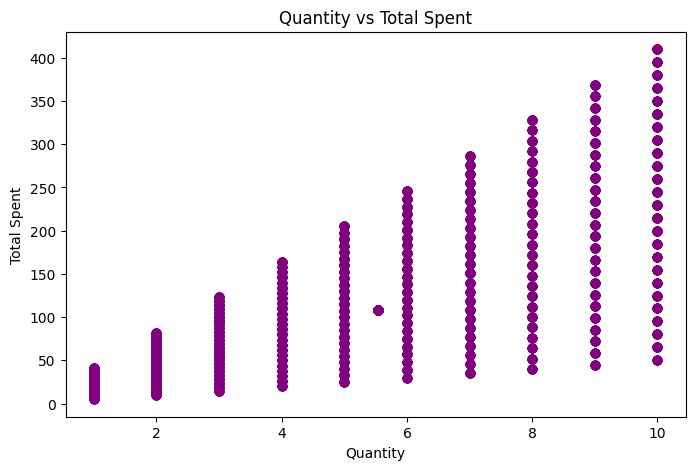

In [22]:
# Scatter plot - Quantity vs Total Spent
plt.figure(figsize=(8, 5))
plt.scatter(df['Quantity'], df['Total Spent'], color='purple', alpha=0.5)
plt.xlabel('Quantity')
plt.ylabel('Total Spent')
plt.title('Quantity vs Total Spent')
plt.show()

### Insight: Quantity vs Total Spent (Scatter Plot)

1. **Correlation**: 
   - **Positive correlation** (upward trend): As quantity increases, total spent also increases — expected behavior.
   - **No correlation** (scattered randomly): Quantity alone doesn't determine spending; price per unit varies significantly.
   - **Clusters**: Groups of points indicate common purchasing patterns.

2. **Linearity**: 
   - If points form a straight line → Strong linear relationship between quantity and spending.
   - If points are spread out → Other factors (discounts, item type) influence total spent.

3. **Outliers**: 
   - Points far from the main cluster may indicate bulk purchases or premium items.

4. **Business Insight**:
   - Customers buying more items tend to spend more (if positive correlation).
   - Consider bundle offers to encourage higher quantity purchases.
   - Identify high-value transactions for loyalty programs.

In [27]:
# EDA for Quantity vs Total Spent
print("📊 EDA: Quantity vs Total Spent")
print("=" * 45)

# Correlation
correlation = df['Quantity'].corr(df['Total Spent'])
print(f"\nPearson Correlation: {correlation:.3f}")
if correlation > 0.7:
    print("→ Strong positive correlation")
elif correlation > 0.4:
    print("→ Moderate positive correlation")
elif correlation > 0:
    print("→ Weak positive correlation")
else:
    print("→ Negative/No correlation")

# Basic stats for both columns
print("\n📈 Quantity Statistics:")
print(f"   Mean: {df['Quantity'].mean():.2f}")
print(f"   Median: {df['Quantity'].median():.2f}")
print(f"   Std Dev: {df['Quantity'].std():.2f}")

print("\n💰 Total Spent Statistics:")
print(f"   Mean: {df['Total Spent'].mean():.2f}")
print(f"   Median: {df['Total Spent'].median():.2f}")
print(f"   Std Dev: {df['Total Spent'].std():.2f}")

# Covariance
covariance = df['Quantity'].cov(df['Total Spent'])
print(f"\nCovariance: {covariance:.2f}")

# Average spent per quantity level
print("\n📦 Average Total Spent by Quantity:")
print(df.groupby('Quantity')['Total Spent'].mean().round(2))

📊 EDA: Quantity vs Total Spent

Pearson Correlation: 0.711
→ Strong positive correlation

📈 Quantity Statistics:
   Mean: 5.54
   Median: 5.54
   Std Dev: 2.79

💰 Total Spent Statistics:
   Mean: 128.64
   Median: 108.50
   Std Dev: 92.56

Covariance: 183.56

📦 Average Total Spent by Quantity:
Quantity
1.00000      23.28
2.00000      46.35
3.00000      68.75
4.00000      94.67
5.00000     118.06
5.53638     108.50
6.00000     139.98
7.00000     162.19
8.00000     186.28
9.00000     209.98
10.00000    238.43
Name: Total Spent, dtype: float64


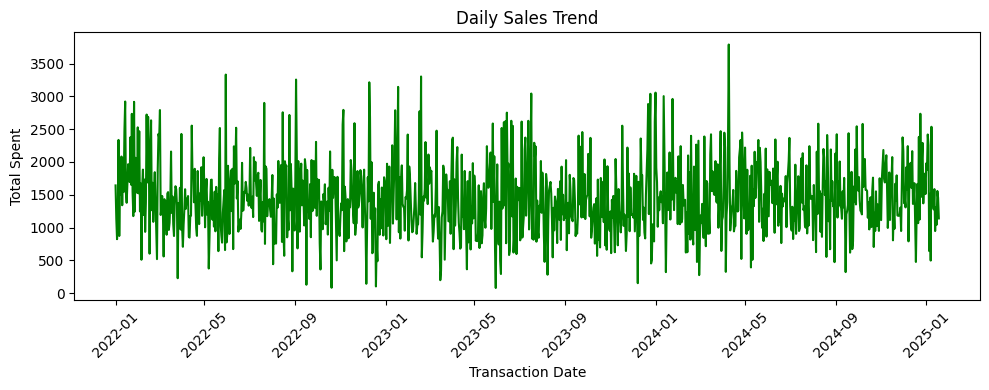

In [23]:
# Convert Date to datetime first
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

# Line plot - Daily sales trend
daily_sales = df.groupby('Transaction Date')['Total Spent'].sum()

plt.figure(figsize=(10, 4))
plt.plot(daily_sales.index, daily_sales.values, color='green')
plt.xlabel('Transaction Date')
plt.ylabel('Total Spent')
plt.title('Daily Sales Trend')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight: Daily Sales Trend (Line Plot)

1. **Overall Trend**:
   - **Upward trend**: Sales are growing over time — positive business growth.
   - **Downward trend**: Sales are declining — may need marketing intervention.
   - **Flat trend**: Sales are stable and consistent.

2. **Seasonality/Patterns**:
   - Recurring peaks may indicate weekends, paydays, or promotional events.
   - Dips could represent weekdays or off-seasons.

3. **Volatility**:
   - High fluctuations suggest inconsistent customer behavior.
   - Smooth line indicates predictable, steady sales.

4. **Peaks & Troughs**:
   - Identify dates with highest sales → Analyze what drove those sales (promotions, holidays).
   - Identify low-performing days → Opportunity for targeted campaigns.

5. **Business Insight**:
   - Plan inventory and staffing based on peak sales days.
   - Schedule promotions during low-sales periods to boost revenue.
   - Monitor trends to forecast future sales.

📊 Correlation Matrix:
                Price Per Unit  Quantity  Total Spent
Price Per Unit           1.000     0.011        0.597
Quantity                 0.011     1.000        0.711
Total Spent              0.597     0.711        1.000


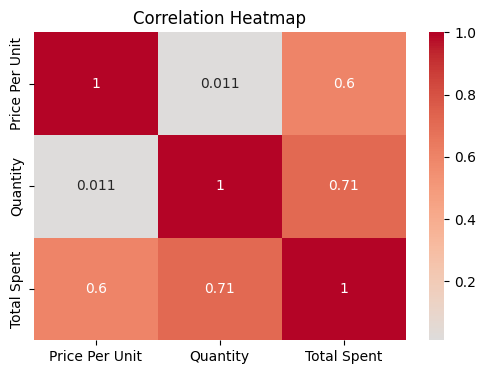

In [25]:
# Correlation matrix for numeric columns
numeric_cols = ['Price Per Unit', 'Quantity', 'Total Spent']
correlation_matrix = df[numeric_cols].corr()
print("📊 Correlation Matrix:")
print(correlation_matrix.round(3))

# Visualize correlation heatmap
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()